In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Todo listo")


Todo listo


In [ ]:

df = pd.read_csv('talentwell_data.csv')

ohe = OneHotEncoder(sparse_output=False, drop='first')
modalidad_encoded = ohe.fit_transform(df[['modalidad']])
nombres_columnas = ohe.get_feature_names_out(['modalidad']).tolist()
for i, col in enumerate(nombres_columnas):
    df[col] = modalidad_encoded[:, i]

features = [
    'horas_trabajo_dia', 'horas_sueno', 'reuniones_dia',
    'actividad_fisica_semanal', 'anios_experiencia',
    'modalidad_presencial', 'modalidad_remoto'
]

X = df[features]
y = df['riesgo_burnout']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba:        {X_test.shape[0]} registros")
print(f"Tasa burnout entrenamiento: {y_train.mean():.2%}")
print(f"Tasa burnout prueba:        {y_test.mean():.2%}")

Entrenamiento: 1200 registros
Prueba:        300 registros
Tasa burnout entrenamiento: 22.83%
Tasa burnout prueba:        23.00%


In [3]:
arbol = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    criterion='gini'   
)
arbol.fit(X_train, y_train)

print("Árbol de decisión entrenado.")
print(f"Profundidad real del árbol: {arbol.get_depth()}")
print(f"Número de hojas (decisiones finales): {arbol.get_n_leaves()}")

Árbol de decisión entrenado.
Profundidad real del árbol: 4
Número de hojas (decisiones finales): 16


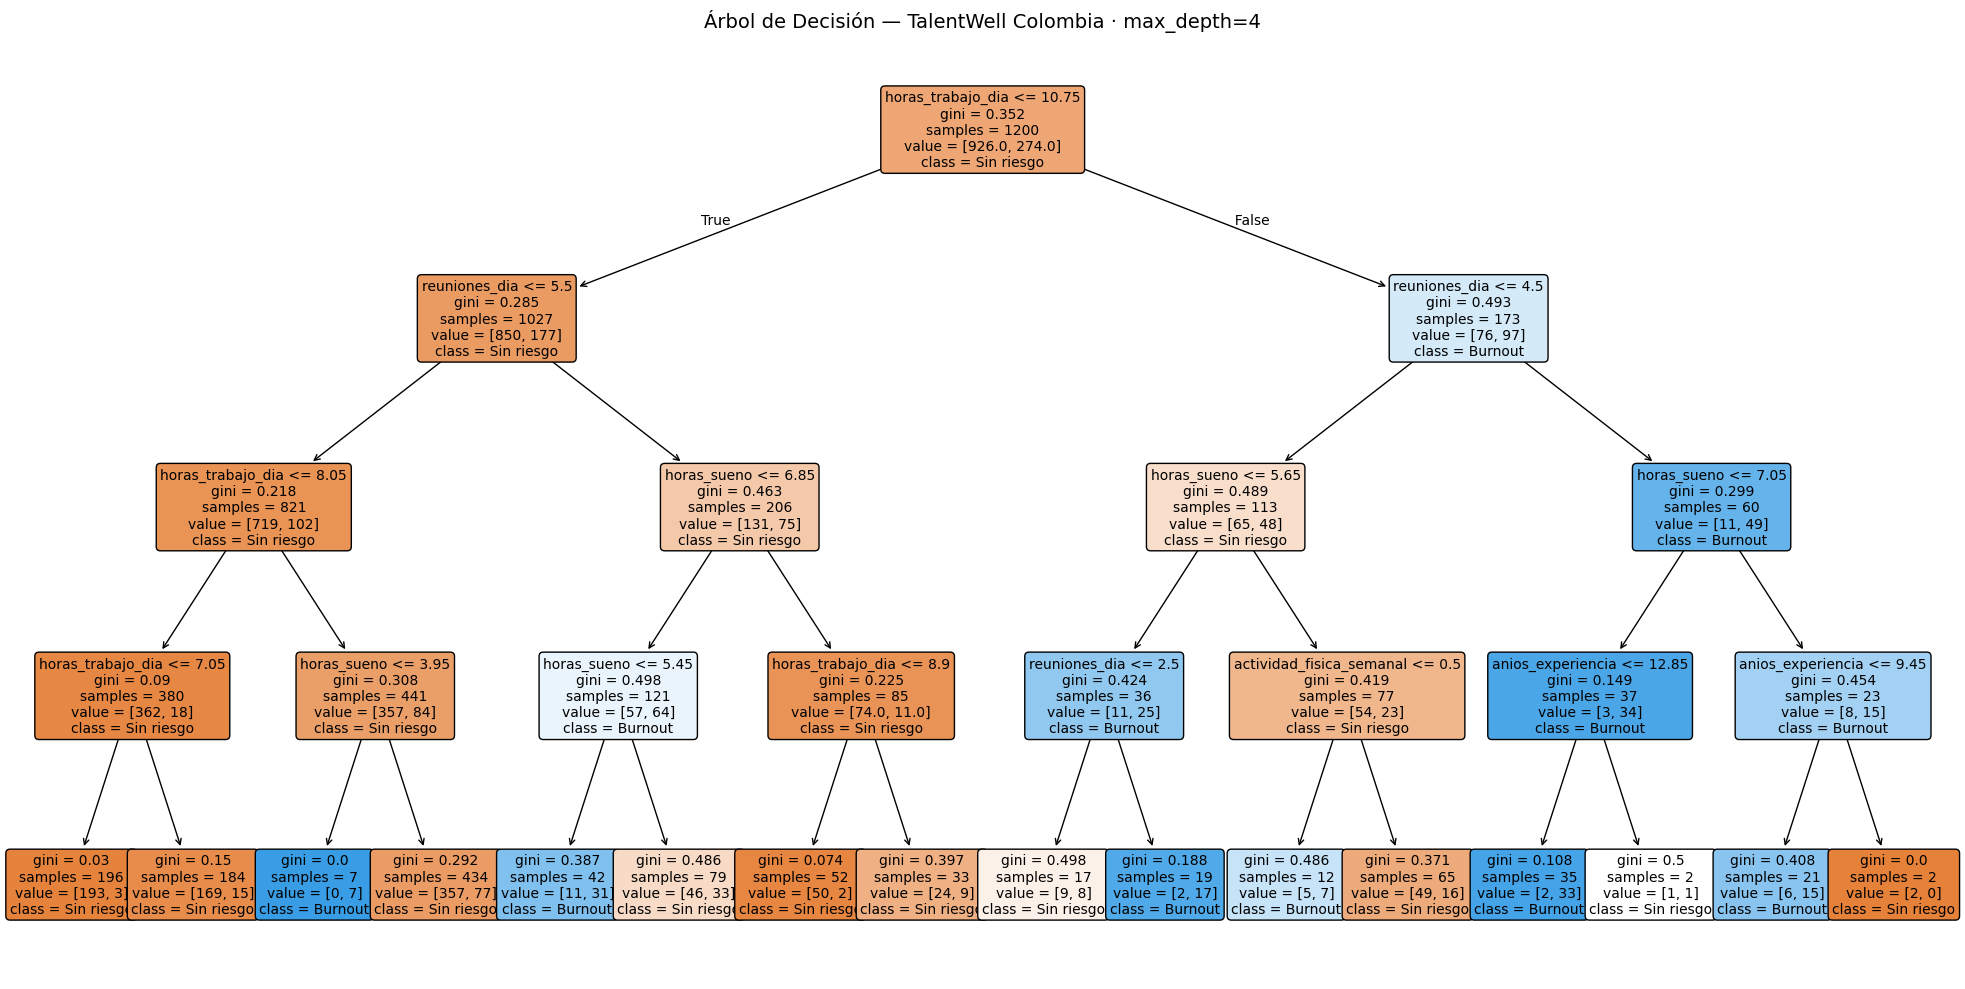

In [4]:
plt.figure(figsize=(20, 10))
plot_tree(
    arbol,
    feature_names=features,
    class_names=['Sin riesgo', 'Burnout'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión — TalentWell Colombia · max_depth=4', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
y_pred_arbol = arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, y_pred_arbol)
baseline = (y_test == 0).mean()

print(f"Accuracy del árbol:         {acc_arbol:.1%}")
print(f"Accuracy modelo estúpido:   {baseline:.1%}")
print(f"Ganancia sobre baseline:    {(acc_arbol - baseline)*100:.1f} puntos porcentuales")
print()
print("=== Reporte por clase ===")
print(classification_report(y_test, y_pred_arbol, target_names=['Sin riesgo', 'Burnout']))

Accuracy del árbol:         81.3%
Accuracy modelo estúpido:   77.0%
Ganancia sobre baseline:    4.3 puntos porcentuales

=== Reporte por clase ===
              precision    recall  f1-score   support

  Sin riesgo       0.83      0.95      0.89       231
     Burnout       0.69      0.35      0.46        69

    accuracy                           0.81       300
   macro avg       0.76      0.65      0.67       300
weighted avg       0.80      0.81      0.79       300



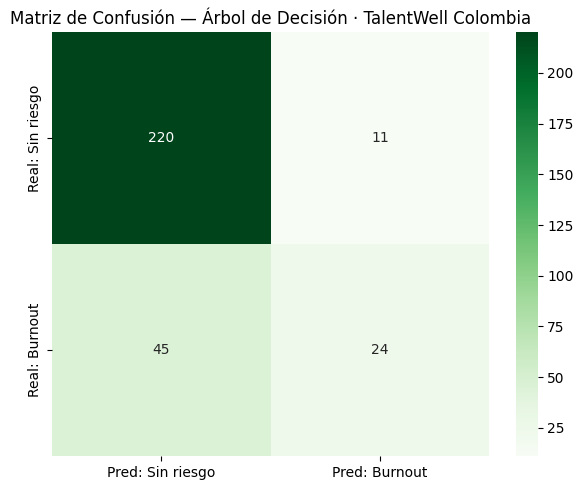

Falsos Negativos (FN): 45  — burnouts reales no detectados ⚠
Verdaderos Positivos (VP): 24  — burnouts correctamente detectados ✓
Recall Burnout = 34.78%


In [6]:
cm_arbol = confusion_matrix(y_test, y_pred_arbol)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_arbol, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Pred: Sin riesgo', 'Pred: Burnout'],
    yticklabels=['Real: Sin riesgo', 'Real: Burnout'],
    ax=ax
)
ax.set_title('Matriz de Confusión — Árbol de Decisión · TalentWell Colombia', fontsize=12)
plt.tight_layout()
plt.show()

vn = cm_arbol[0, 0]
fp = cm_arbol[0, 1]
fn = cm_arbol[1, 0]
vp = cm_arbol[1, 1]

print(f"Falsos Negativos (FN): {fn}  — burnouts reales no detectados ⚠")
print(f"Verdaderos Positivos (VP): {vp}  — burnouts correctamente detectados ✓")
print(f"Recall Burnout = {vp/(vp+fn):.2%}")


=== Importancia de variables (árbol de decisión) ===
                 feature  importancia
       horas_trabajo_dia     0.412930
             horas_sueno     0.298953
           reuniones_dia     0.251964
       anios_experiencia     0.019189
actividad_fisica_semanal     0.016964
    modalidad_presencial     0.000000
        modalidad_remoto     0.000000

Suma de importancias: 1.0000  (siempre debe ser 1.0)


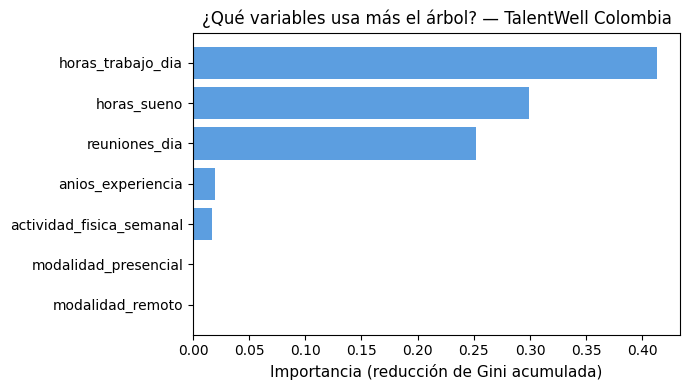

In [7]:
importancias = pd.DataFrame({
    'feature':    features,
    'importancia': arbol.feature_importances_
}).sort_values('importancia', ascending=False)

print("=== Importancia de variables (árbol de decisión) ===")
print(importancias.to_string(index=False))
print(f"\nSuma de importancias: {importancias['importancia'].sum():.4f}  (siempre debe ser 1.0)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importancias['feature'], importancias['importancia'], color='#5c9ee0')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Importancia (reducción de Gini acumulada)', fontsize=11)
ax.set_title('¿Qué variables usa más el árbol? — TalentWell Colombia', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
